In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
import pandas as pd

SEED = 123
np.random.seed(SEED)
neighbors = 2

In [41]:

distance_matrix = np.load('../duomenys/dist_mat.npy')
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
vertimai = {
    "Cargo": "Krovininiai",
    "Fishing": "Žvejybiniai",
    "Passenger": "Keleiviniai",
    "Pilot": "Locmanai",
    "Tanker": "Tanklaiviai"
}

label_names = {
    i: vertimai.get(str(name), str(name))
    for i, name in enumerate(unique_labels)
}

print(label_names)

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)


DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)


{0: 'Krovininiai', 1: 'Žvejybiniai', 2: 'Keleiviniai', 3: 'Locmanai', 4: 'Tanklaiviai'}


In [42]:
# aibiu padalijimas  (70/30)
idx_train, idx_test = train_test_split(
    np.arange(n_samples), test_size=0.3, random_state=SEED, stratify=labels_encoded
)

X_train_tsne, X_test_tsne = embedding[idx_train], embedding[idx_test]
y_train_tsne, y_test_tsne = labels_encoded[idx_train], labels_encoded[idx_test]

X_train_orig, X_test_orig = original_flat[idx_train], original_flat[idx_test]
y_train_orig, y_test_orig = labels_encoded[idx_train], labels_encoded[idx_test]

print(len(idx_train))
print(len(idx_test))



525
225


In [43]:

# KNN originalioje dimensijoje;
# normavimas + mokymas + metrikos

def run_knn(X_train, X_test, y_train, y_test, label_names, title_prefix, k=neighbors):
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)

    classes = np.unique(np.concatenate([y_train, y_test]))
    cm = confusion_matrix(y_test, y_pred, labels=classes)

    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm,
                         index=[label_names[c] for c in classes],
                         columns=[label_names[c] for c in classes])
    print(cm_df.to_string())

    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)

    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n

    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in classes]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")

    return clf, X_train_sc, X_test_sc, scaler



In [44]:
# 2D skiriamieji pavirsiai

def plot_decision_boundary(clf, X_train_sc, X_test_sc,
                           y_train, y_test, label_names,
                           title, ax, step=0.3):
    unique_classes = np.unique(np.concatenate([y_train, y_test]))

    x_min = min(X_train_sc[:,0].min(), X_test_sc[:,0].min()) - 1
    x_max = max(X_train_sc[:,0].max(), X_test_sc[:,0].max()) + 1
    y_min = min(X_train_sc[:,1].min(), X_test_sc[:,1].min()) - 1
    y_max = max(X_train_sc[:,1].max(), X_test_sc[:,1].max()) + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_train == cls
        ax.scatter(X_train_sc[mask, 0], X_train_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")




═════════════════════════════════════════════════════════════════
  KRYŽMINĖ PATIKRA (5-fold Stratified KFold) — originalūs duomenys (mokymo aibė)
═════════════════════════════════════════════════════════════════
   k |  F1 vidurkis |   F1 std | Acc vidurkis |  Acc std
-----------------------------------------------------------------
   2 |       0.7284 |   0.0274 |       0.7257 |   0.0251
   3 |       0.7237 |   0.0342 |       0.7200 |   0.0354
   4 |       0.7153 |   0.0292 |       0.7124 |   0.0285
   5 |       0.7109 |   0.0229 |       0.7086 |   0.0260
   7 |       0.6653 |   0.0365 |       0.6629 |   0.0393
  11 |       0.6520 |   0.0407 |       0.6476 |   0.0409
  15 |       0.6253 |   0.0266 |       0.6210 |   0.0279

→ Geriausias k = 2  (F1 = 0.7284 ± 0.0274)


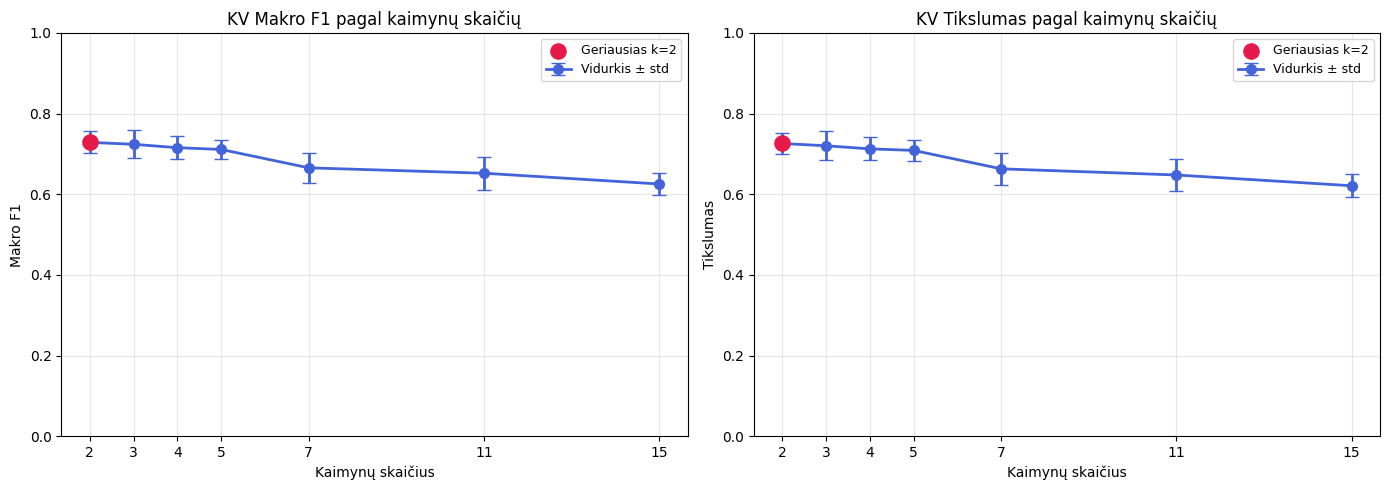

In [45]:

# ═════════════════════════════════════════════════════════════════════════════
# GERIAUSIO k PAIEŠKA — Stratified K-Fold kryžminė patikra
# Pipeline: StandardScaler + KNN (normavimas kiekviename fold'e atskirai)
# ═════════════════════════════════════════════════════════════════════════════
K_LIST = [2, 3, 4, 5, 7, 11, 15]
N_FOLDS = 5 # 10-fold stratified CV

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_results = {}
for k in K_LIST:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_validate(
        pipe, X_train_orig, y_train_orig, cv=cv,  # tik mokymo aibė
        scoring={"f1": "f1_macro", "acc": "accuracy"},
        return_train_score=False
    )
    cv_results[k] = {
        "f1_mean":  scores["test_f1"].mean(),
        "f1_std":   scores["test_f1"].std(),
        "acc_mean": scores["test_acc"].mean(),
        "acc_std":  scores["test_acc"].std(),
        "f1_folds": scores["test_f1"],
        "acc_folds": scores["test_acc"],
    }

# ── Lentelė
print("\n" + "═"*65)
print(f"  KRYŽMINĖ PATIKRA ({N_FOLDS}-fold Stratified KFold) — originalūs duomenys (mokymo aibė)")
print("═"*65)
print(f"{'k':>4} | {'F1 vidurkis':>12} | {'F1 std':>8} | {'Acc vidurkis':>12} | {'Acc std':>8}")
print("-"*65)
for k in K_LIST:
    r = cv_results[k]
    print(f"{k:>4} | {r['f1_mean']:>12.4f} | {r['f1_std']:>8.4f} "
          f"| {r['acc_mean']:>12.4f} | {r['acc_std']:>8.4f}")

best_k = max(K_LIST, key=lambda k: cv_results[k]["f1_mean"])
print(f"\n→ Geriausias k = {best_k}  "
      f"(F1 = {cv_results[best_k]['f1_mean']:.4f} ± {cv_results[best_k]['f1_std']:.4f})")

# ── Vizualizacija: CV rezultatai
fig_cv, axes_cv = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in zip(axes_cv, ["f1", "acc"], ["Makro F1", "Tikslumas"]):
    means = [cv_results[k][f"{metric}_mean"] for k in K_LIST]
    stds  = [cv_results[k][f"{metric}_std"]  for k in K_LIST]

    ax.errorbar(K_LIST, means, yerr=stds, fmt='o-', capsize=5,
                color='#4363D8', linewidth=2, markersize=7, label='Vidurkis ± std')

    # Pažymėti geriausią k
    best_val = cv_results[best_k][f"{metric}_mean"]
    ax.scatter([best_k], [cv_results[best_k][f"{metric}_mean"]],
               color='#E6194B', s=120, zorder=5, label=f'Geriausias k={best_k}')

    ax.set_xlabel("Kaimynų skaičius")
    ax.set_ylabel(ylabel)
    ax.set_title(f"KV {ylabel} pagal kaimynų skaičių")
    ax.set_xticks(K_LIST)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('./plots/knn_cv.svg', format='svg')
plt.show()


In [46]:
# KNN klasifikavimas 2D

print("\nKNN klasifikavimas sumažintoje 2D dimensijoje (t-SNE)")
clf_tsne, Xtr_tsne_sc, Xte_tsne_sc, sc_tsne = run_knn(
    X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne,
    label_names, title_prefix="t-SNE erdvė", k=neighbors
)


KNN klasifikavimas sumažintoje 2D dimensijoje (t-SNE)
Klasifikavimo lentele (true/pred)
             Krovininiai  Žvejybiniai  Keleiviniai  Locmanai  Tanklaiviai
Krovininiai           36            2            2         1            4
Žvejybiniai            9           32            1         0            3
Keleiviniai            9            2           29         2            3
Locmanai               7            2            6        30            0
Tanklaiviai           15            3            2         1           24

Metrikos kiekvienai klasei:
             precision  recall      f1
Krovininiai     0.4737  0.8000  0.5950
Žvejybiniai     0.7805  0.7111  0.7442
Keleiviniai     0.7250  0.6444  0.6824
Locmanai        0.8824  0.6667  0.7595
Tanklaiviai     0.7059  0.5333  0.6076

Accuracy      : 0.6711
Macro precision : 0.7135
Macro recall    : 0.6711
Macro F1        : 0.6777


In [47]:
# KNN klasifikavimas originaliems duomenims
print("\nKNN klasifikavimas originaliems duomenims")
clf_orig, Xtr_orig_sc, Xte_orig_sc, sc_orig = run_knn(
    X_train_orig, X_test_orig, y_train_orig, y_test_orig,
    label_names, title_prefix="Originalūs duomenys", k=neighbors
)



KNN klasifikavimas originaliems duomenims
Klasifikavimo lentele (true/pred)
             Krovininiai  Žvejybiniai  Keleiviniai  Locmanai  Tanklaiviai
Krovininiai           40            3            2         0            0
Žvejybiniai           11           33            0         0            1
Keleiviniai            6            4           32         2            1
Locmanai               4            4           11        26            0
Tanklaiviai           15            8            1         1           20

Metrikos kiekvienai klasei:
             precision  recall      f1
Krovininiai     0.5263  0.8889  0.6612
Žvejybiniai     0.6346  0.7333  0.6804
Keleiviniai     0.6957  0.7111  0.7033
Locmanai        0.8966  0.5778  0.7027
Tanklaiviai     0.9091  0.4444  0.5970

Accuracy      : 0.6711
Macro precision : 0.7324
Macro recall    : 0.6711
Macro F1        : 0.6689


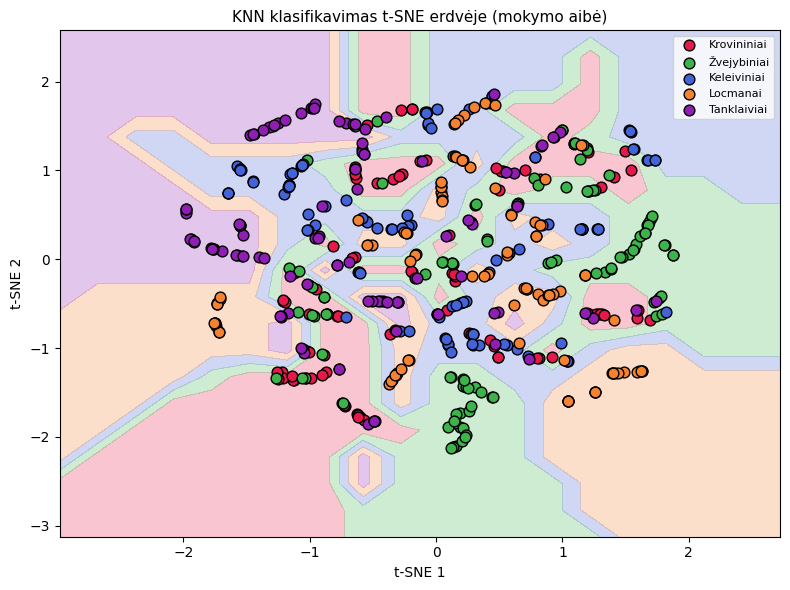

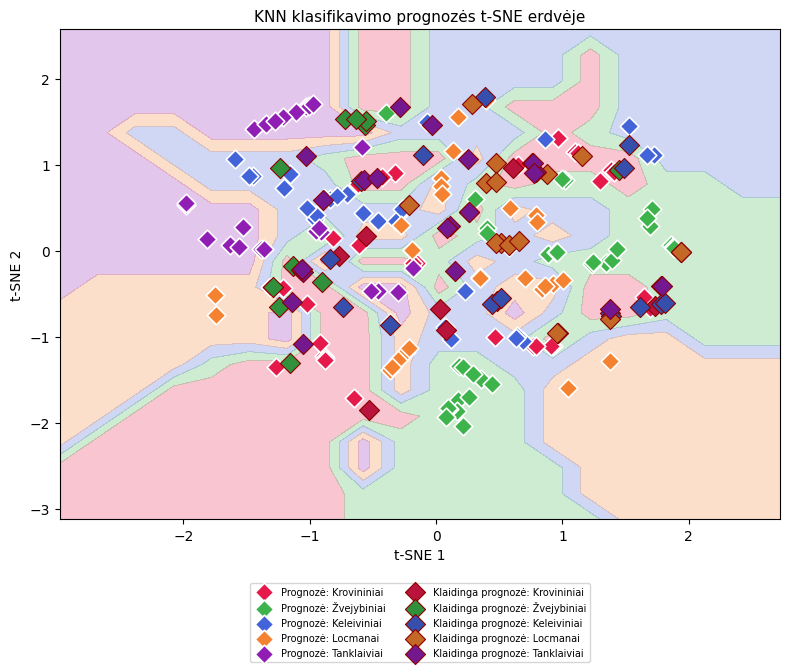

In [49]:
# 1. Gauname prognozes testavimo aibei t-SNE erdvėje
y_pred_tsne = clf_tsne.predict(Xte_tsne_sc)

# 2. Pirmas grafikas: mokymo aibė
fig, ax = plt.subplots(figsize=(8, 6))

plot_decision_boundary(
    clf_tsne,
    Xtr_tsne_sc,
    Xte_tsne_sc,
    y_train_tsne,
    y_train_tsne,
    label_names,
    title="KNN klasifikavimas t-SNE erdvėje (mokymo aibė)",
    ax=ax
)

ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()


import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

def darken_color(color, amount=0.15):
    """
    Patamsina spalvą.

    amount = 0.00 -> originali spalva
    amount = 0.10 -> šiek tiek tamsesnė
    amount = 0.30 -> aiškiai tamsesnė
    amount = 1.00 -> juoda
    """
    rgb = np.array(mcolors.to_rgb(color))
    dark_rgb = rgb * (1 - amount)
    return dark_rgb


# Prognozės testavimo aibei t-SNE erdvėje
y_pred_tsne = clf_tsne.predict(Xte_tsne_sc)

# Antras grafikas: tik testavimo prognozės
fig, ax = plt.subplots(figsize=(8, 7))

plot_decision_boundary(
    clf_tsne,
    Xtr_tsne_sc,
    Xte_tsne_sc,
    y_train_tsne,
    y_test_tsne,
    label_names,
    title="KNN klasifikavimo prognozės t-SNE erdvėje",
    ax=ax
)

# Pašaliname taškus, kuriuos nubraižė plot_decision_boundary,
# paliekame tik sprendimo ribų foną
for collection in ax.collections[1:]:
    collection.remove()


# Teisingos ir klaidingos prognozės
errors = y_pred_tsne != y_test_tsne
correct = ~errors


# Teisingos prognozės
for cls in np.unique(y_test_tsne):
    mask = (y_test_tsne == cls) & correct
    
    ax.scatter(
        Xte_tsne_sc[mask, 0],
        Xte_tsne_sc[mask, 1],
        c=[class_colors[cls]],
        edgecolors="white",
        linewidths=1.2,
        s=90,
        marker="D",
        zorder=4,
        label=f"Prognozė: {label_names[cls]}"
    )


# Klaidingos prognozės: šiek tiek tamsesnės spalvos + tamsiai raudonas kontūras
darkness_amount = 0.2

for cls in np.unique(y_test_tsne):
    mask = (y_test_tsne == cls) & errors
    
    ax.scatter(
        Xte_tsne_sc[mask, 0],
        Xte_tsne_sc[mask, 1],
        c=[darken_color(class_colors[cls], amount=darkness_amount)],
        edgecolors="#8B0000",
        linewidths=0.8,
        s=105,
        marker="D",
        zorder=5,
        label=f"Klaidinga prognozė: {label_names[cls]}"
    )


ax.legend(
    fontsize=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

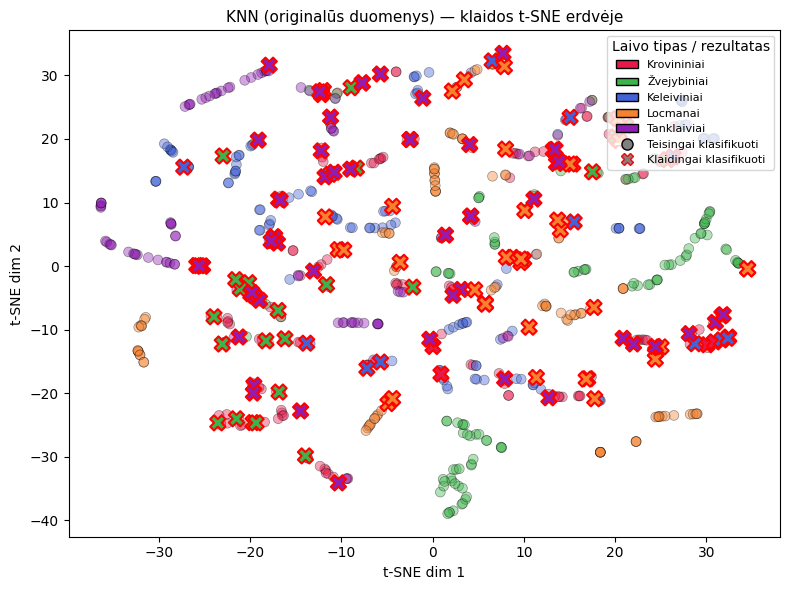

In [50]:

# originaliu duomenu klaidos t-SNE 

fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred_full = clf_orig.predict(sc_orig.transform(original_flat))
correct = y_pred_full == labels_encoded

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(embedding[correct, 0], embedding[correct, 1],
            c=[class_colors[c] for c in labels_encoded[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(embedding[~correct, 0], embedding[~correct, 1],
            c=[class_colors[c] for c in labels_encoded[~correct]],
            s=120, edgecolors='red', linewidths=1.5, marker='X', alpha=1.0, zorder=3)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
class_patches = [Patch(facecolor=class_colors[i], edgecolor='k',
                       label=label_names[i]) for i in unique_cls]
marker_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='k', markersize=8, label='Teisingai klasifikuoti'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='gray',
           markeredgecolor='red', markersize=8, label='Klaidingai klasifikuoti'),
]
ax2.legend(handles=class_patches + marker_handles, fontsize=8,
           loc='upper right', title="Laivo tipas / rezultatas")
ax2.set_title("KNN (originalūs duomenys) — klaidos t-SNE erdvėje", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/knn_errors_orig.svg', format='svg')
plt.show()


In [ ]:
mmsis_raw = np.load('../mmsis.npy')

# Get one MMSI per trajectory (they repeat per time step)
# Assuming trajectories are grouped consecutively
n_samples = original_data.shape[0]
points_per_trajectory = len(mmsis_raw) // n_samples
mmsis = mmsis_raw[::points_per_trajectory]  # take first MMSI of each trajectory

print(f"MMSIs per trajectory check: {mmsis.shape}")  # should be (750,)

print(f"\nCorrectly classified: {correct.sum()} / {len(correct)}")
print(f"Misclassified:        {(~correct).sum()} / {len(correct)}")

print("\nMisclassified MMSIs:")
for i in np.where(~correct)[0]:
    true_label = label_names[labels_encoded[i]]
    pred_label = label_names[y_pred_full[i]]
    print(f"  MMSI {mmsis[i]}  |  true: {true_label:20s}  |  predicted: {pred_label}")

MMSIs per trajectory check: (818,)

Correctly classified: 614 / 750
Misclassified:        136 / 750

Misclassified MMSIs:
  MMSI 209764000  |  true: Cargo                 |  predicted: Tanker
  MMSI 209764000  |  true: Cargo                 |  predicted: Fishing
  MMSI 209864000  |  true: Cargo                 |  predicted: Fishing
  MMSI 209864000  |  true: Cargo                 |  predicted: Fishing
  MMSI 209968000  |  true: Cargo                 |  predicted: Tanker
  MMSI 211325510  |  true: Cargo                 |  predicted: Fishing
  MMSI 211325510  |  true: Cargo                 |  predicted: Fishing
  MMSI 211325510  |  true: Cargo                 |  predicted: Fishing
  MMSI 211787800  |  true: Cargo                 |  predicted: Fishing
  MMSI 211787800  |  true: Cargo                 |  predicted: Fishing
  MMSI 211787800  |  true: Cargo                 |  predicted: Tanker
  MMSI 212112000  |  true: Cargo                 |  predicted: Fishing
  MMSI 212112000  |  true: Ca

In [ ]:
import numpy as np
import pandas as pd
import folium

CSV_PATH      = '../duomenys/data.csv'
OUTPUT_HTML   = 'trajectories_npy.html'

MMSIS_PATH         = '../duomenys/mmsis.npy'
SHIP_INDICES_PATH  = '../duomenys/ship_indices.npy'
ORIGINAL_DATA_PATH = '../duomenys/original_data.npy'
SHIP_TYPES_PATH    = '../duomenys/ship-types.npy'

# Dict: MMSI -> [predicted_labels]  (true label comes from ship_types[i])
MISCLASSIFIED_PREDS = {
    209764000: ['Tanker', 'Fishing'],
    209864000: ['Fishing', 'Fishing'],
    209968000: ['Tanker'],
    211325510: ['Fishing', 'Fishing', 'Fishing'],
    211787800: ['Fishing', 'Fishing', 'Tanker'],
    212112000: ['Fishing', 'Fishing', 'Passenger'],
    215064000: ['Tanker'],
    219001058: ['Cargo', 'Cargo', 'Cargo', 'Cargo', 'Cargo', 'Cargo'],
    219022256: ['Tanker', 'Cargo', 'Tanker', 'Cargo'],
    219023911: ['Cargo', 'Tanker', 'Cargo'],
    219024176: ['Cargo', 'Cargo', 'Cargo', 'Cargo', 'Cargo', 'Cargo'],
    219024675: ['Cargo', 'Cargo', 'Cargo', 'Cargo'],
    219026443: ['Tanker', 'Cargo', 'Cargo', 'Cargo'],
    219030955: ['Pilot', 'Cargo', 'Cargo', 'Fishing'],
    219423000: ['Cargo', 'Cargo', 'Fishing'],
    219560000: ['Pilot', 'Pilot', 'Fishing', 'Pilot', 'Fishing', 'Tanker', 'Cargo', 'Tanker', 'Fishing'],
    219707000: ['Cargo', 'Tanker'],
    235090537: ['Fishing'],
    248886000: ['Tanker', 'Fishing', 'Pilot'],
    256212000: ['Fishing'],
    256784000: ['Passenger', 'Passenger', 'Passenger', 'Cargo', 'Fishing'],
    257186000: ['Cargo', 'Passenger', 'Cargo', 'Passenger'],
    265028000: ['Passenger', 'Cargo'],
    265031000: ['Tanker', 'Passenger', 'Cargo', 'Fishing'],
    265504660: ['Passenger', 'Cargo', 'Cargo', 'Cargo'],
    265527020: ['Cargo', 'Passenger'],
    265610940: ['Passenger', 'Cargo', 'Passenger', 'Tanker', 'Passenger', 'Cargo', 'Cargo', 'Cargo', 'Cargo'],
    265610950: ['Cargo', 'Cargo', 'Fishing', 'Cargo', 'Cargo', 'Fishing', 'Passenger', 'Cargo', 'Cargo', 'Pilot'],
    265754000: ['Cargo', 'Fishing', 'Cargo', 'Cargo'],
    266239000: ['Cargo', 'Fishing', 'Cargo', 'Cargo', 'Cargo', 'Cargo', 'Passenger', 'Fishing', 'Cargo', 'Cargo'],
    266262000: ['Cargo', 'Fishing', 'Cargo', 'Cargo'],
    266352000: ['Cargo', 'Cargo', 'Cargo', 'Cargo', 'Cargo'],
    266435000: ['Fishing', 'Cargo', 'Fishing', 'Cargo', 'Fishing'],
}
MISCLASSIFIED_MMSIS = set(MISCLASSIFIED_PREDS.keys())

TYPE_COLORS = {
    'Cargo':     '#4363D8',
    'Fishing':   '#3CB44B',
    'Passenger': '#F58231',
    'Pilot':     '#911EB4',
    'Tanker':    '#E6194B',
}

print("Loading npy files...")
mmsis         = np.load(MMSIS_PATH, allow_pickle=True)
ship_indices  = np.load(SHIP_INDICES_PATH, allow_pickle=True)
original_data = np.load(ORIGINAL_DATA_PATH, allow_pickle=True)
ship_types    = np.load(SHIP_TYPES_PATH, allow_pickle=True)

mmsis_per_traj = mmsis[ship_indices]

print("Reading lat/lon bounds from CSV...")
df_bounds = pd.read_csv(CSV_PATH, engine='pyarrow', usecols=['Latitude', 'Longitude'])
lat_min, lat_max = df_bounds['Latitude'].min(), df_bounds['Latitude'].max()
lon_min, lon_max = df_bounds['Longitude'].min(), df_bounds['Longitude'].max()
print(f"Lat: [{lat_min:.4f}, {lat_max:.4f}]  Lon: [{lon_min:.4f}, {lon_max:.4f}]")
del df_bounds

lats = original_data[:, :, 0] * (lat_max - lat_min) + lat_min
lons = original_data[:, :, 1] * (lon_max - lon_min) + lon_min

m = folium.Map(location=[lats.mean(), lons.mean()], zoom_start=6,
               tiles='CartoDB dark_matter')

type_groups = {}
for t in TYPE_COLORS:
    fg = folium.FeatureGroup(name=f'<span style="color:{TYPE_COLORS[t]}">■</span> {t}', show=True)
    m.add_child(fg)
    type_groups[t] = fg
other_group = folium.FeatureGroup(name='Other', show=True)
m.add_child(other_group)

print(f"Plotting {len(mmsis_per_traj)} trajectories...")
for i in range(len(mmsis_per_traj)):
    mmsi       = int(mmsis_per_traj[i])
    true_type  = str(ship_types[i])          # ground truth from npy
    color      = TYPE_COLORS.get(true_type, '#888888')
    is_wrong   = mmsi in MISCLASSIFIED_MMSIS

    coords = list(zip(lats[i], lons[i]))
    coords = [(la, lo) for la, lo in coords if not (la == lat_min and lo == lon_min)]
    if len(coords) < 2:
        continue

    weight  = 6   if is_wrong else 1
    opacity = 1.0 if is_wrong else 0.25
    dash    = None if is_wrong else '4 6'

    if is_wrong:
        preds        = MISCLASSIFIED_PREDS[mmsi]
        unique_preds = list(dict.fromkeys(preds))
        pred_colored = ''.join(
            f'<span style="color:{TYPE_COLORS.get(p, "#888")}">■</span> {p}&nbsp;&nbsp;'
            for p in unique_preds
        )
        classification_rows = f"""
            <tr>
                <td style="color:#aaa; padding-right:10px">True type</td>
                <td><span style="color:{TYPE_COLORS.get(true_type, '#888')}">■</span> <b>{true_type}</b></td>
            </tr>
            <tr>
                <td style="color:#aaa; padding-right:10px; vertical-align:top">Predicted as</td>
                <td>{pred_colored}</td>
            </tr>
            <tr>
                <td colspan="2" style="color:#ff6666; padding-top:6px">
                    ⚠ Misclassified ({len(preds)} segment{'s' if len(preds) > 1 else ''})
                </td>
            </tr>
        """
        tooltip_text = f"MMSI {mmsi} | {true_type} → {', '.join(unique_preds)}"
    else:
        classification_rows = '<tr><td colspan="2" style="color:#44cc44">✓ Correctly classified</td></tr>'
        tooltip_text = f"MMSI {mmsi} — {true_type}"

    popup_html = f"""
    <div style="font-family: monospace; font-size: 12px; min-width: 230px; line-height: 1.8;">
        <b style="font-size: 13px;">MMSI {mmsi}</b>
        <table style="width: 100%; border-collapse: collapse; margin-top: 8px;">
            <tr><td style="color:#aaa; padding-right:10px">Points</td><td>{len(coords)}</td></tr>
            {classification_rows}
        </table>
    </div>
    """

    folium.PolyLine(
        coords, color=color, weight=weight, opacity=opacity,
        dash_array=dash,
        tooltip=tooltip_text,
        popup=folium.Popup(popup_html, max_width=270),
    ).add_to(type_groups.get(true_type, other_group))

    folium.CircleMarker(
        location=coords[0], radius=8 if is_wrong else 2,
        color='white' if is_wrong else color, weight=2 if is_wrong else 1,
        fill=True, fill_color=color, fill_opacity=1.0,
        tooltip=f"Start — {tooltip_text}",
    ).add_to(type_groups.get(true_type, other_group))

    folium.RegularPolygonMarker(
        location=coords[-1], number_of_sides=4,
        radius=8 if is_wrong else 2,
        color='white' if is_wrong else color, weight=2 if is_wrong else 1,
        fill=True, fill_color=color, fill_opacity=1.0,
        tooltip=f"End — {tooltip_text}",
    ).add_to(type_groups.get(true_type, other_group))

folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
     background: rgba(20,20,20,0.88); color: #eee; padding: 14px 18px;
     border-radius: 8px; font-family: monospace; font-size: 13px; line-height: 2;">
  <b>Ship types</b><br>
"""
for t, c in TYPE_COLORS.items():
    legend_html += f'  <span style="color:{c}">━━</span> {t}<br>'
legend_html += """
  <hr style="border-color:#555; margin: 6px 0;">
  <span style="border-bottom: 2px solid #fff;">━━</span> Misclassified (thick)<br>
  <span style="opacity:0.5">╌╌</span> Correct (dashed, faint)<br>
  ● start &nbsp; ■ end<br>
  <i style="font-size:11px; color:#aaa">Click a line for true → predicted labels</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save(OUTPUT_HTML)
print(f"\nSaved → {OUTPUT_HTML}")

Loading npy files...
Reading lat/lon bounds from CSV...
Lat: [54.1152, 56.0000]  Lon: [12.0000, 16.4471]
Plotting 750 trajectories...

Saved → trajectories_npy.html
